In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("KERAS_BACKEND", "tensorflow")
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")

PROJECT_ROOT = Path("/Users/yimingzang/Documents/Project/benchmark2")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import bayesflow as bf

INFO:jax._src.xla_bridge:Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/anaconda3/envs/benchmark2/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file), '/usr/local/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache)
INFO:bayesflow:Using backend 'jax'


In [2]:
from benchmark.examples.diffusion.config import MODELS, TrainingConfig
from benchmark.examples.diffusion.simulators import SIMULATORS
from benchmark.examples.diffusion.approximators.indirect import (
    load_approximator,
    load_history,
)

In [3]:
config = TrainingConfig(summary_multiplier=1)

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

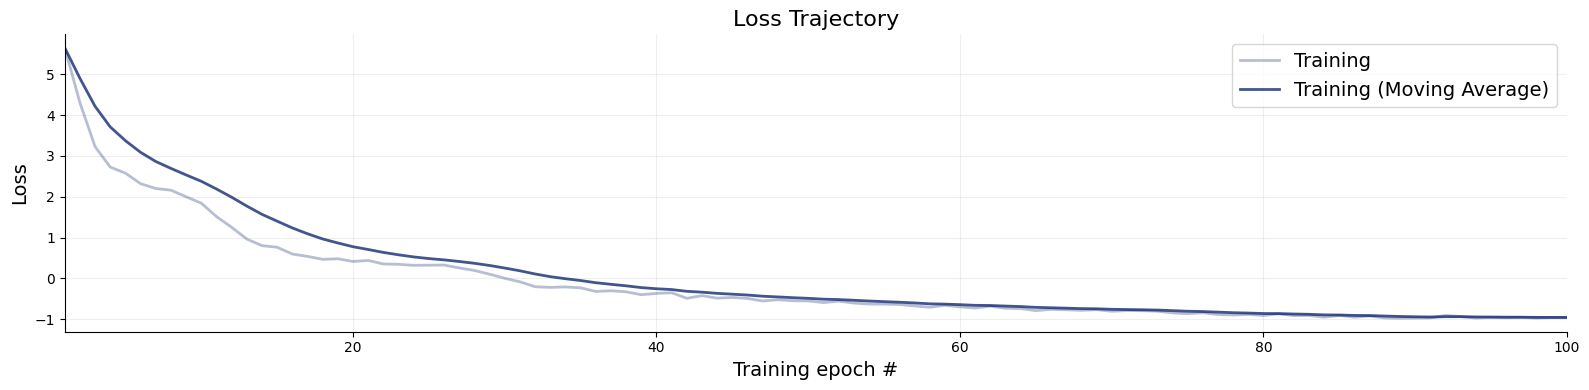

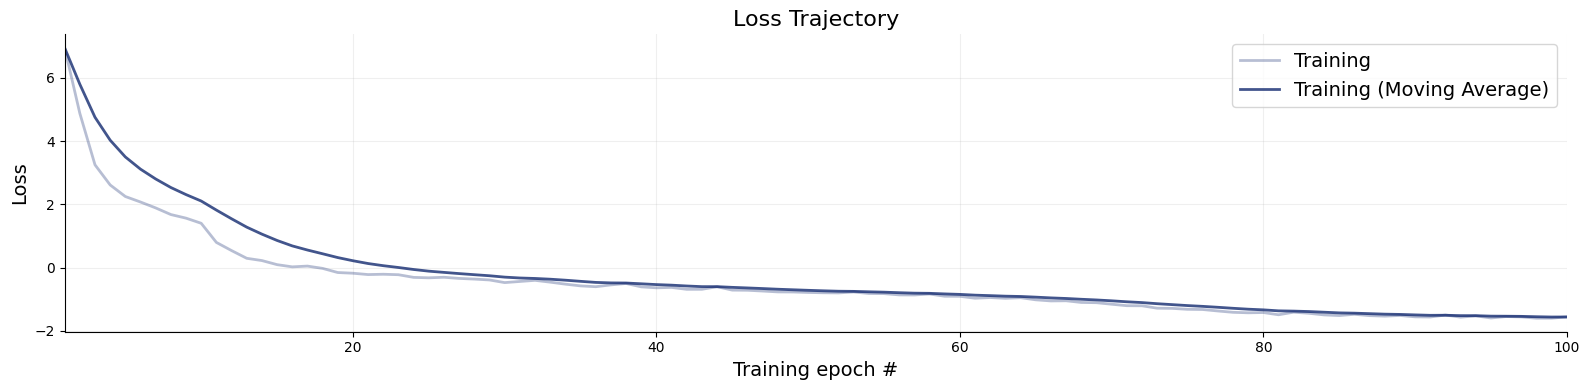

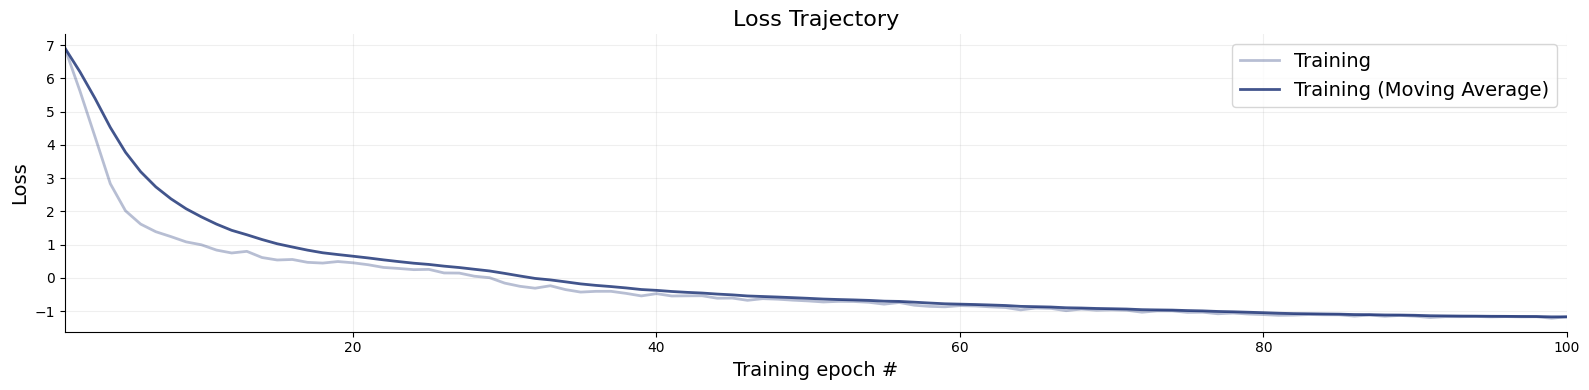

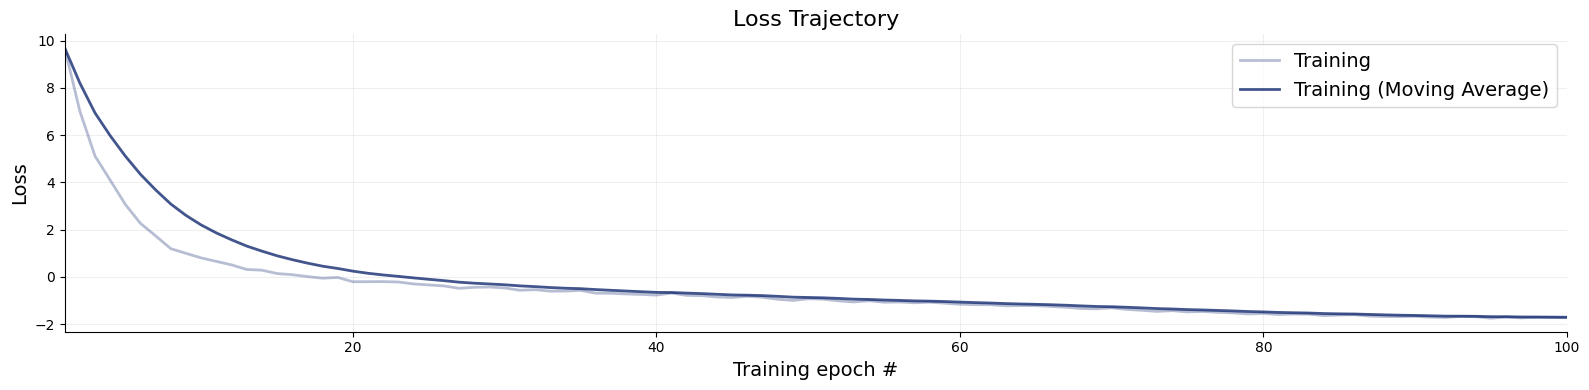

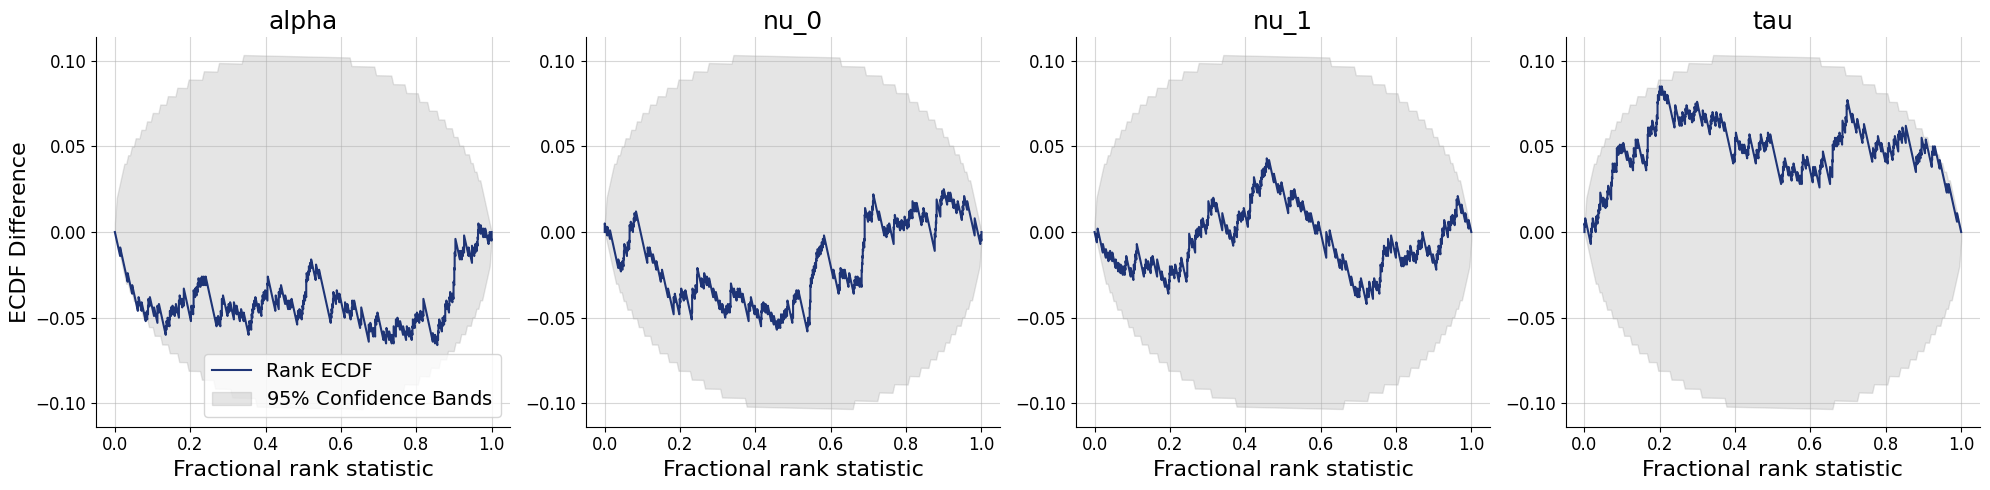

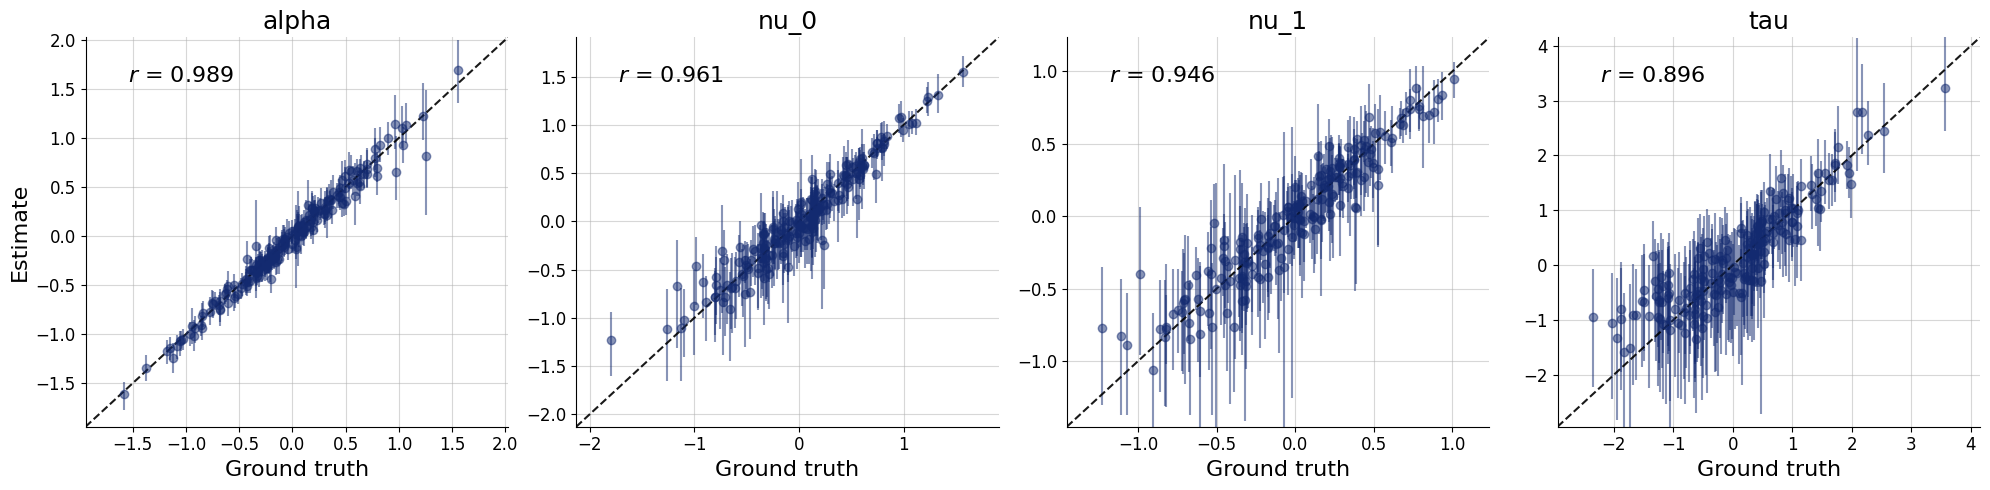

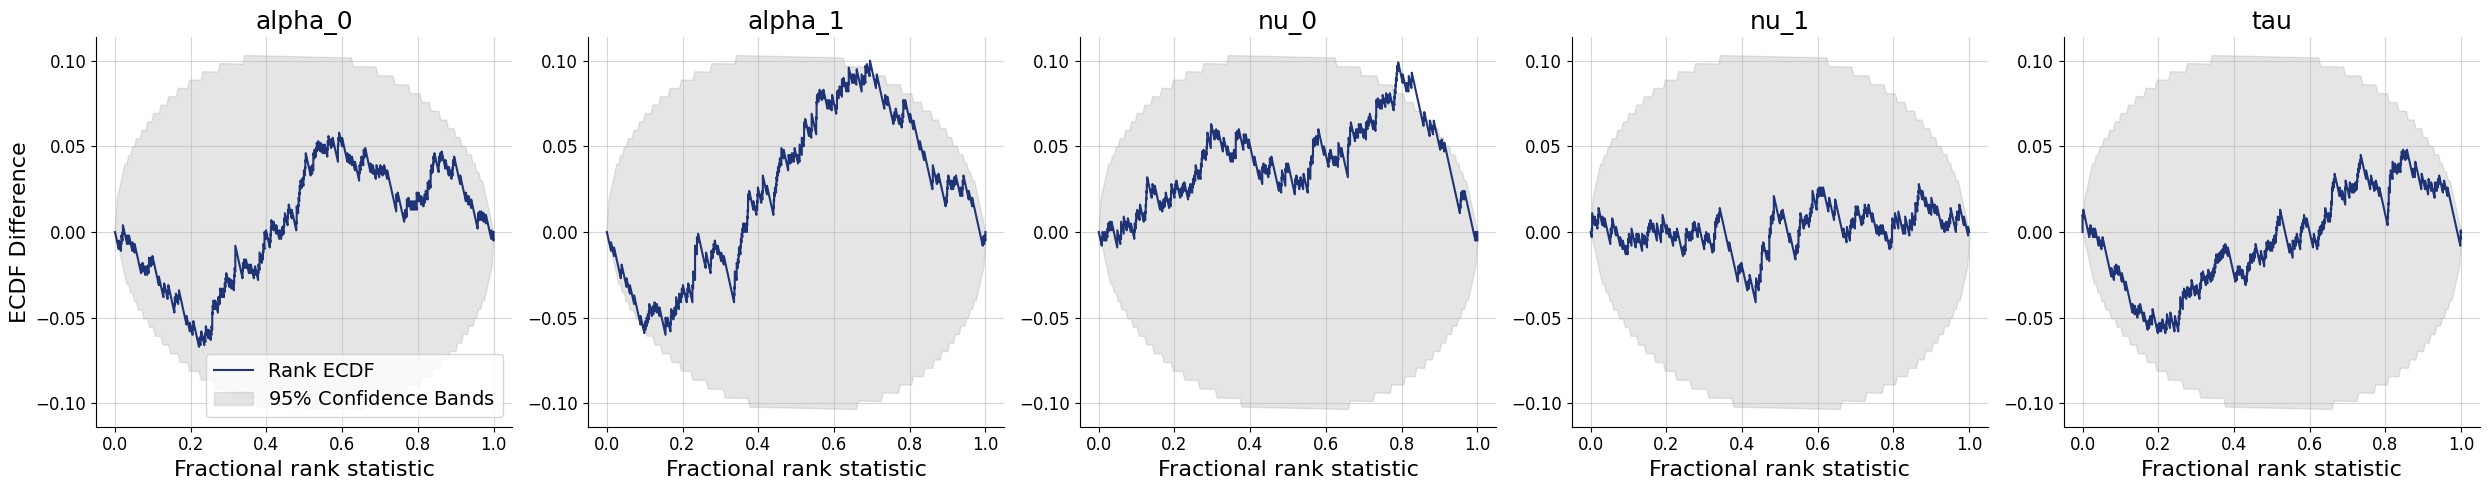

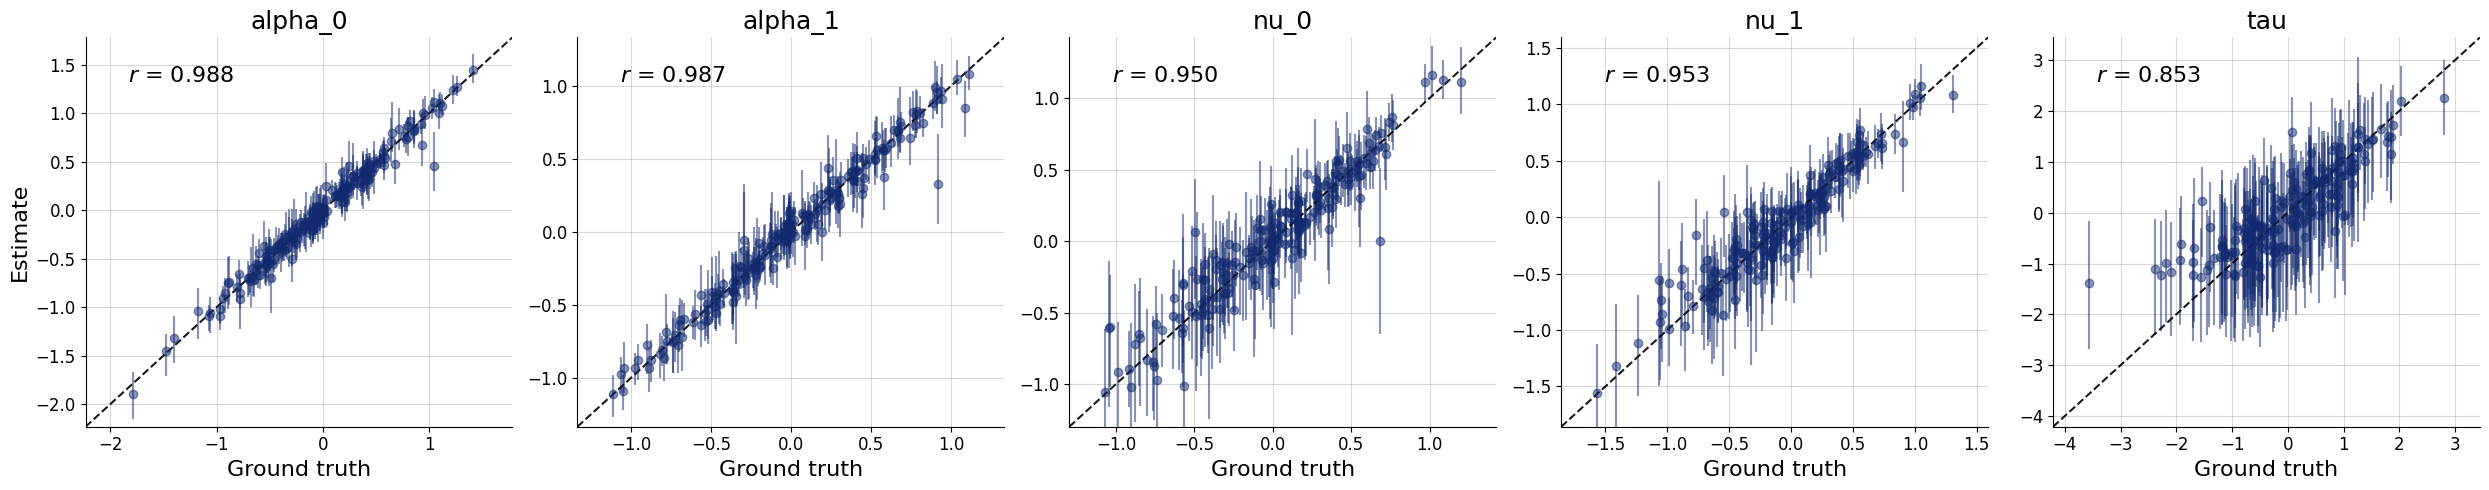

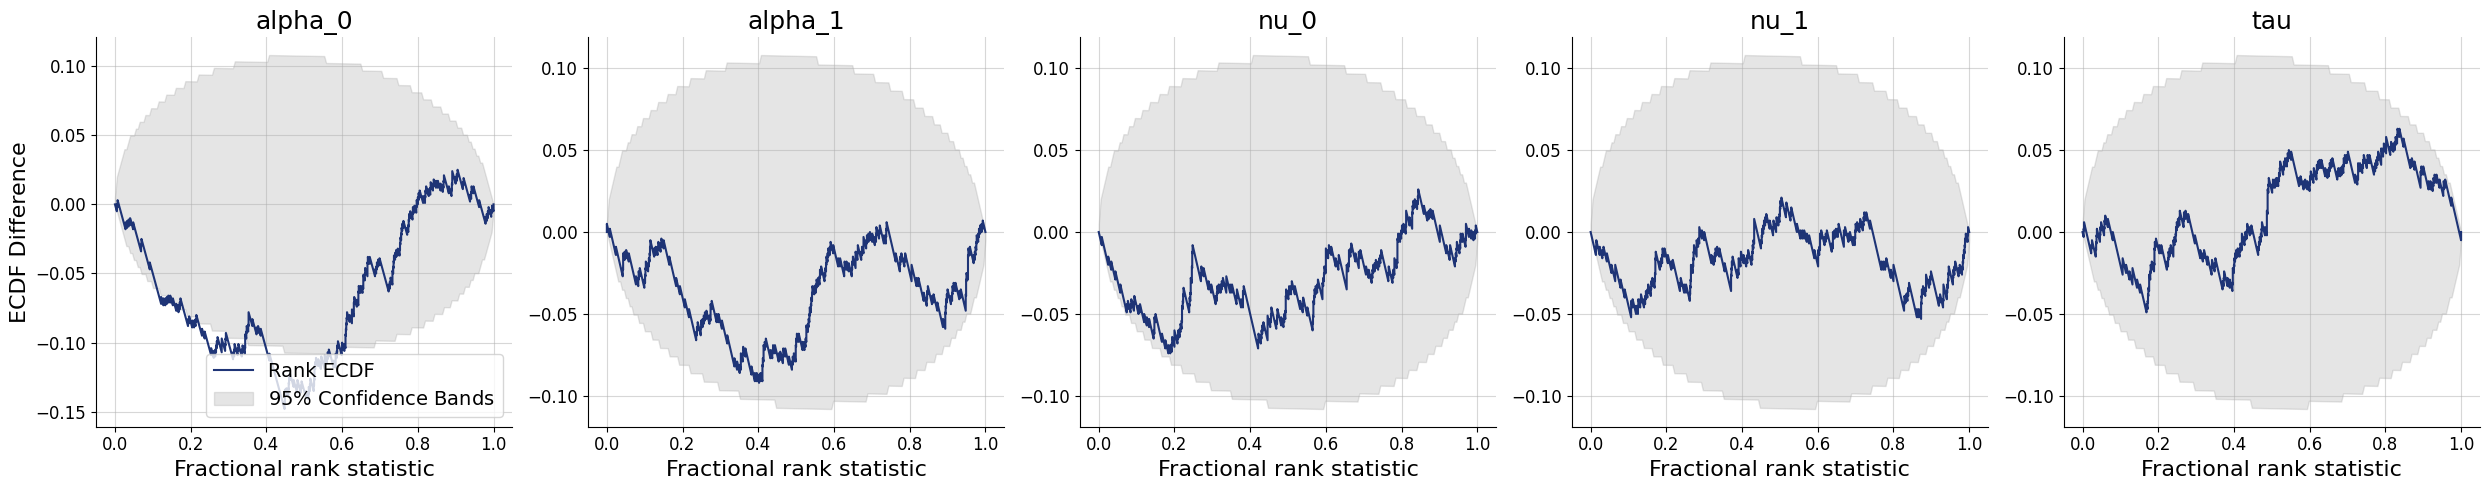

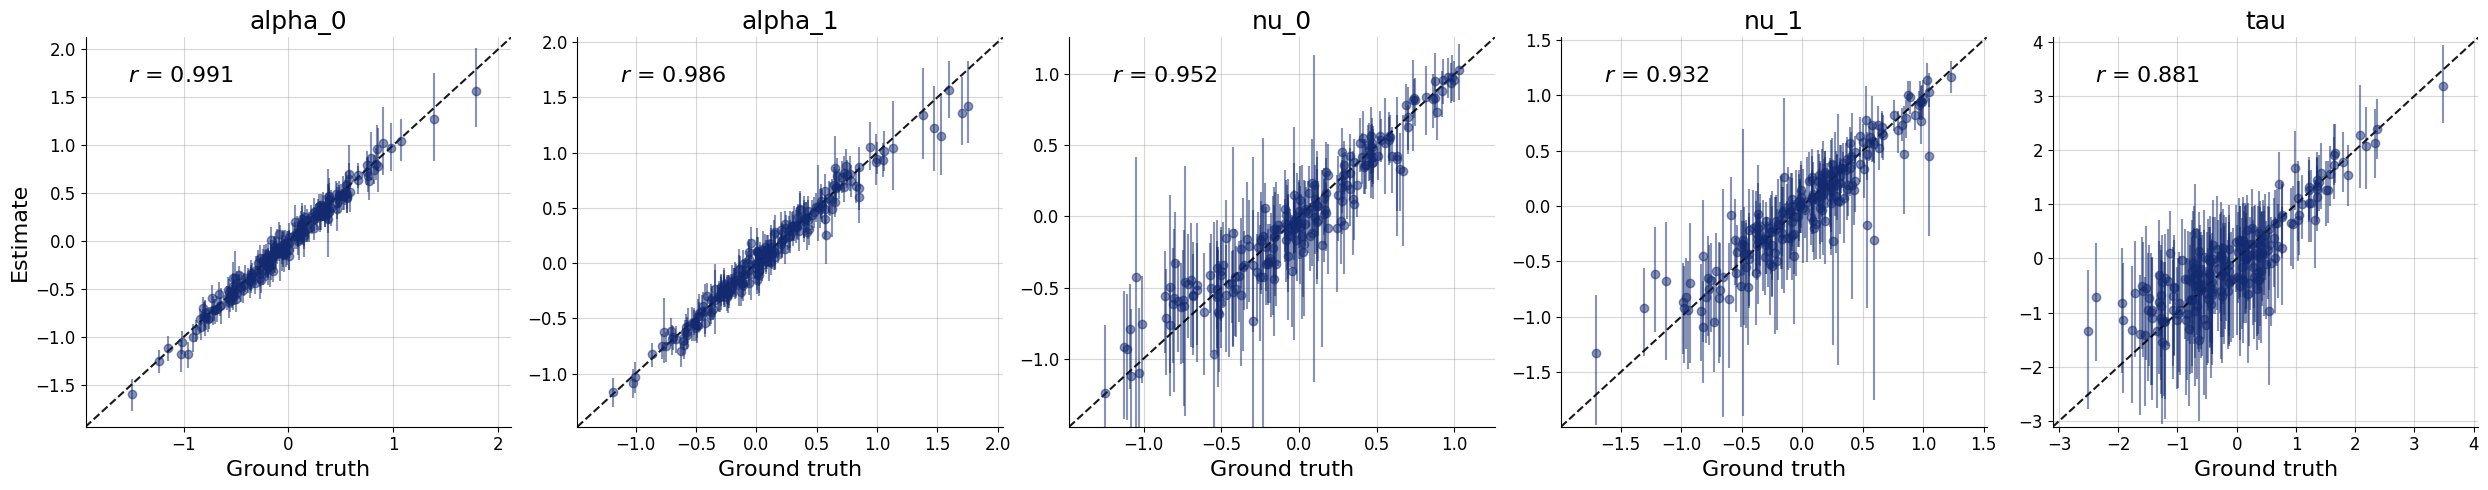

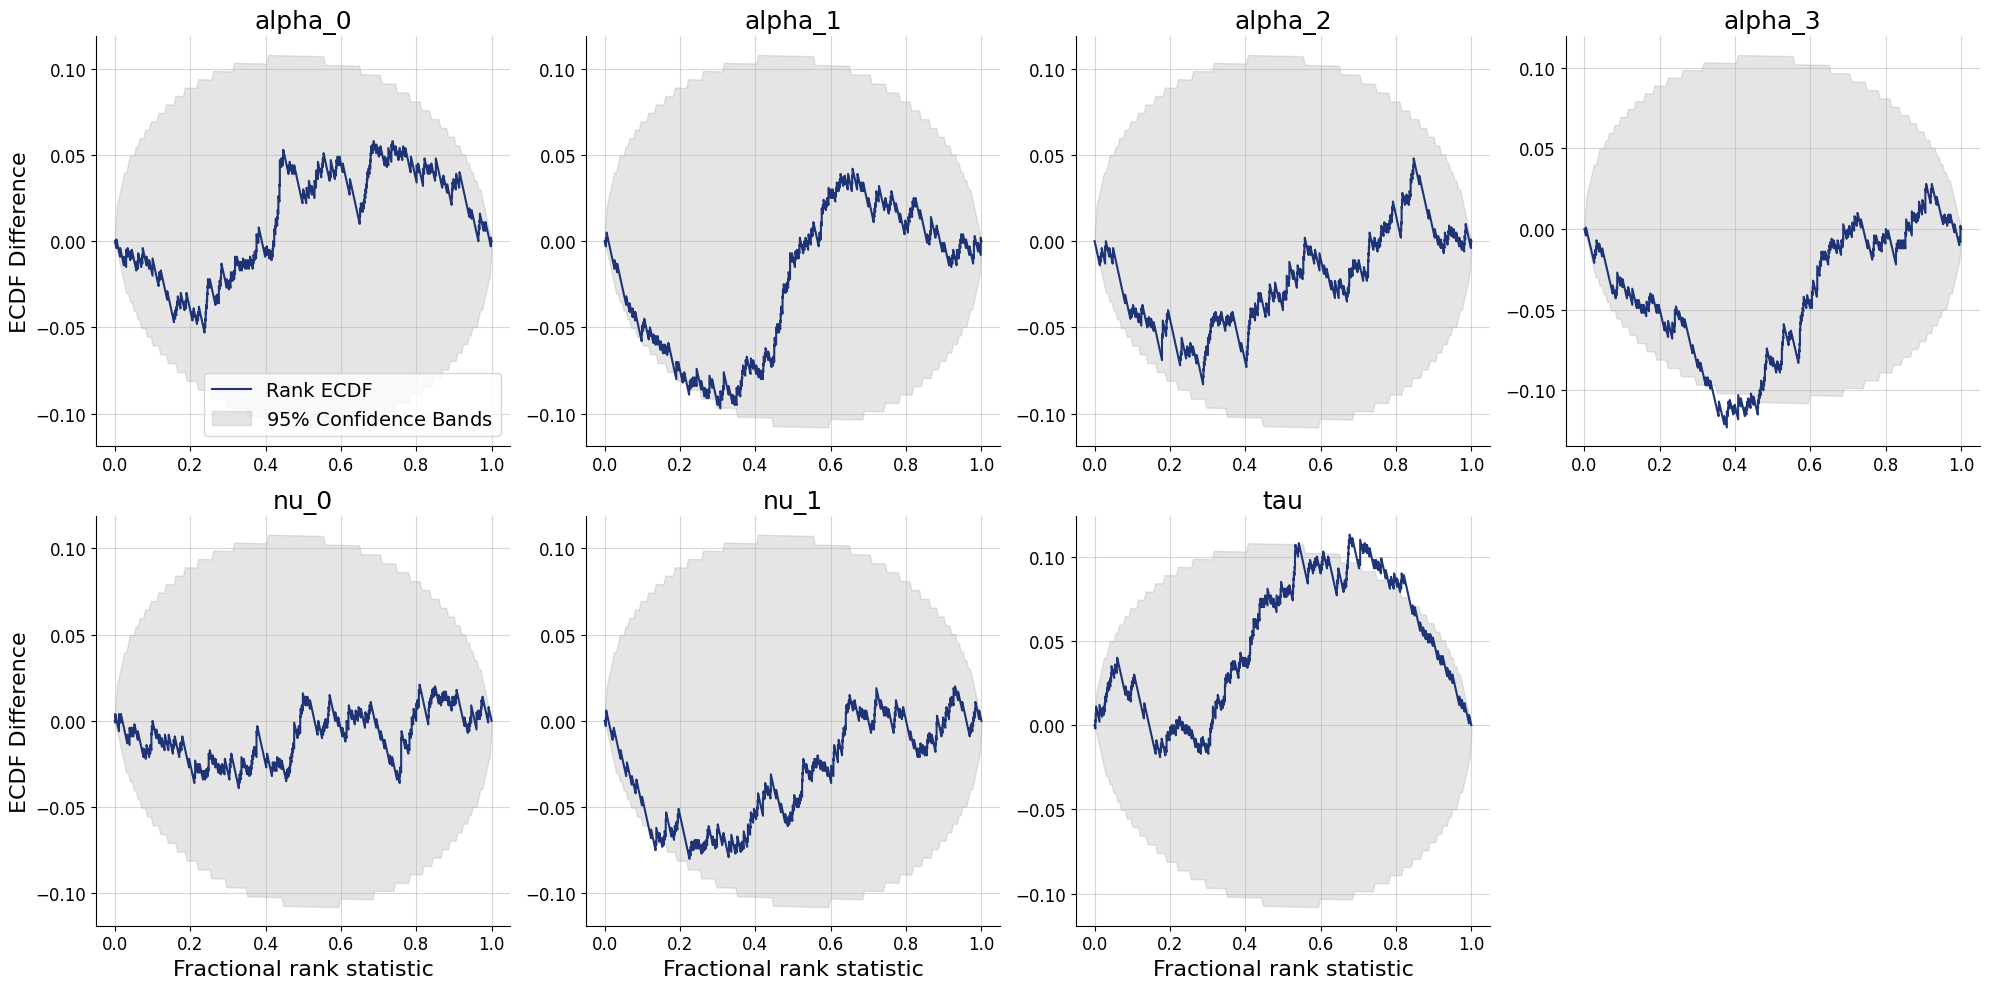

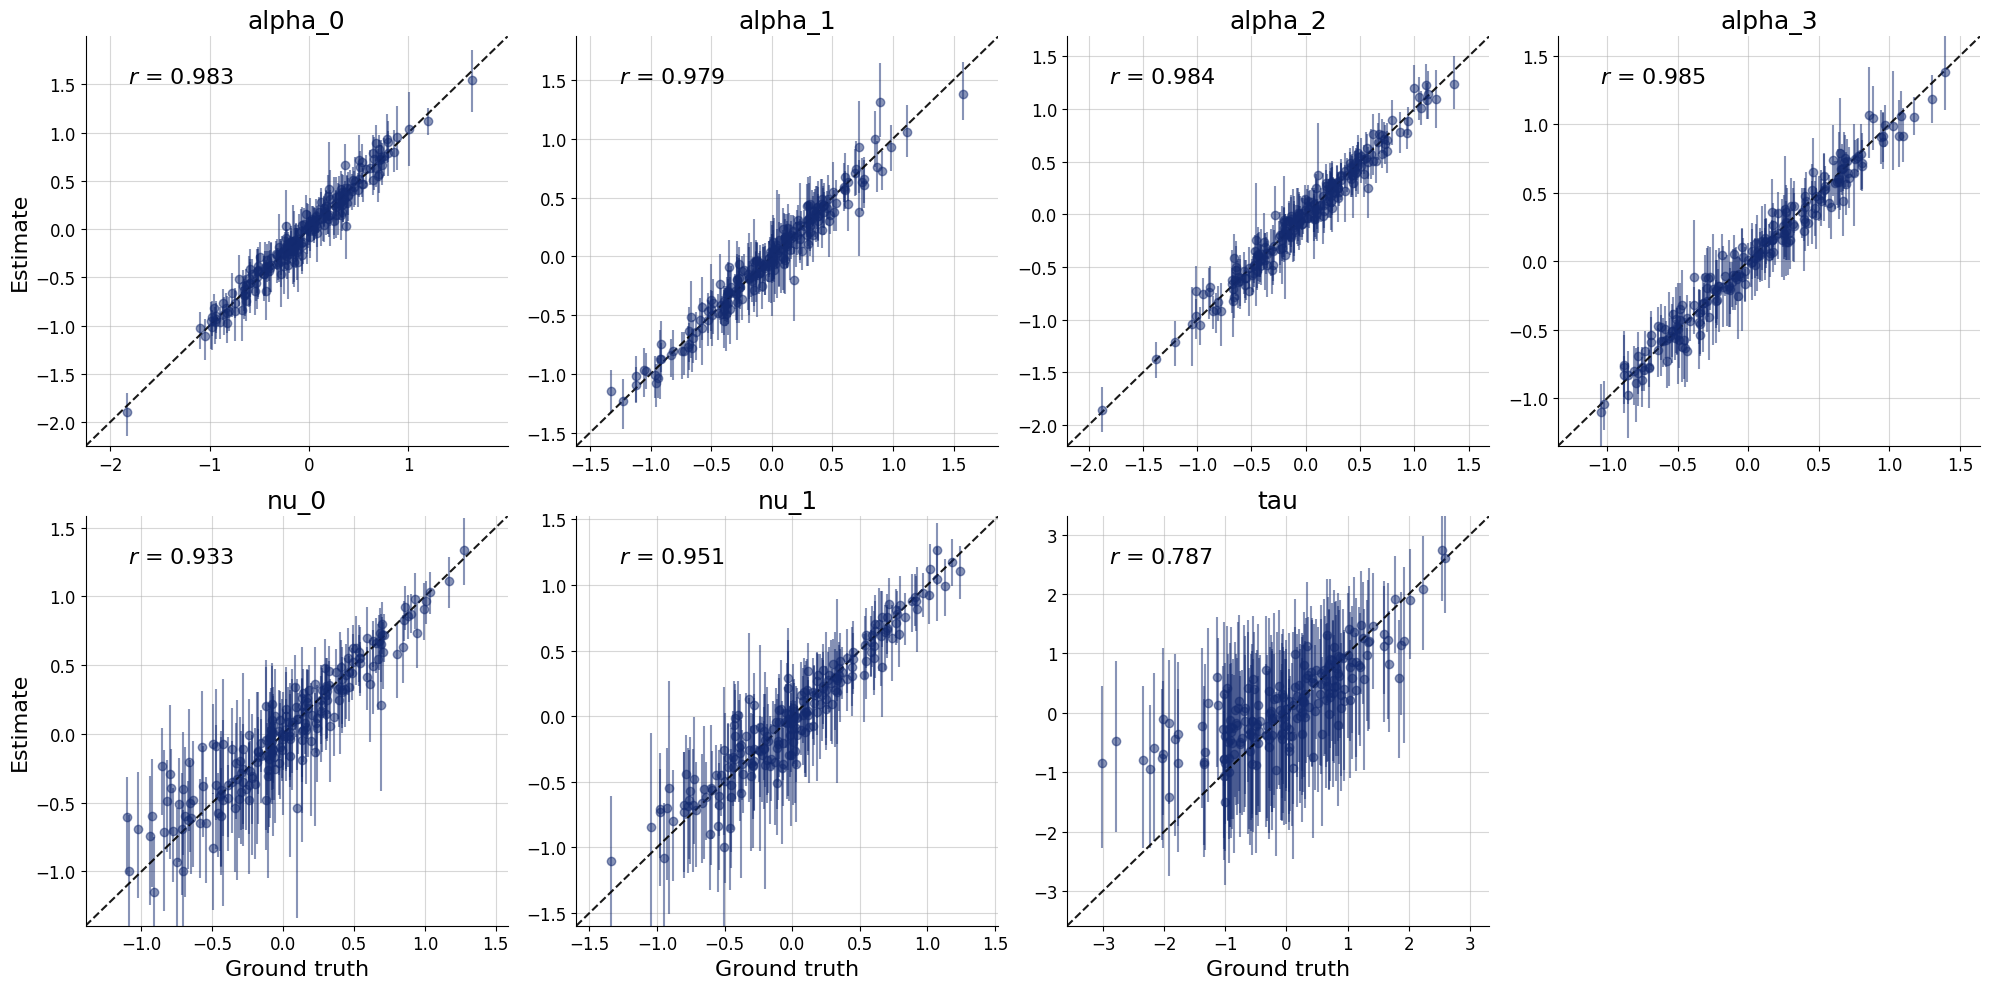

In [4]:
approximators = {model: load_approximator(model, config=config) for model in MODELS}
histories = {model: load_history(model, config=config) for model in MODELS}

for model in MODELS:
    bf.diagnostics.plots.loss(histories[model])

num_samples = 1000
for model in MODELS:
    calibration_sims = SIMULATORS[model].sample(200)
    post_draws = approximators[model].sample(
        conditions=calibration_sims, num_samples=num_samples
    )
    bf.diagnostics.plots.calibration_ecdf(post_draws, calibration_sims, difference=True)
    bf.diagnostics.plots.recovery(post_draws, calibration_sims)